# CONUS Great Plain domain forecast checks

In [1]:
import os
import sys
import yaml
import argparse
from glob import glob
from datetime import datetime, timedelta

import numpy as np
import xarray as xr

sys.path.insert(0, os.path.realpath('../libs/'))
import graph_utils as gu
#import verif_utils as vu

In [2]:
import cmaps
# graph tools
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import matplotlib.colors as colors
import matplotlib.colorbar as cbar
import matplotlib.ticker as ticker
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import cartopy.crs as ccrs
import cartopy.mpl.geoaxes
import cartopy.feature as cfeature

%matplotlib inline

In [3]:
fig_keys = {
    'dpi':250, 
    'orientation':'portrait', 
    'bbox_inches':'tight', 
    'pad_inches':0.1, 
    'transparent':False
}

In [4]:
need_publish = True

if need_publish:
    dpi_ = 75 #fig_keys['dpi']
else:
    dpi_ = 75

In [5]:
def subset_patch(
    ds: xr.Dataset,
    input_size,
    start,   # (ilat0, ilon0). If None → center crop
    lat_name = "yIndex",
    lon_name = "xIndex",
) -> xr.Dataset:
    """
    Return a spatial subset of shape (time, input_size[0], input_size[1]).
    Assumes ds has dims (time, lat, lon).
    """
    H = ds.dims[lat_name]
    W = ds.dims[lon_name]
    h, w = input_size

    if h > H or w > W:
        raise ValueError(f"Requested patch {h}x{w} exceeds dataset size {H}x{W}")

    if start is None:
        i0 = (H - h) // 2
        j0 = (W - w) // 2
    else:
        i0, j0 = start
        if i0 < 0 or j0 < 0 or i0 + h > H or j0 + w > W:
            raise ValueError(f"Start {(i0, j0)} with size {(h, w)} is out of bounds for {H}x{W}")

    i1 = i0 + h
    j1 = j0 + w

    return ds.isel({lat_name: slice(i0, i1), lon_name: slice(j0, j1)})

## Prep data

In [6]:
# WRF_ind0 = 85; WRF_ind1 = 245
# ERA5_ind0 = 57; ERA5_ind1 = 70

In [7]:
fn_target = '/glade/derecho/scratch/ksha/FastEddy/FE_04lev/experiment_11.zarr'
ds_target = xr.open_zarr(fn_target).isel(time=slice(1, None))
ds_sub = subset_patch(ds_target, input_size=(256, 256), start=None)
u_target = ds_sub['u'].values
v_target = ds_sub['v'].values
w_target = ds_sub['w'].values
rho_target = ds_sub['rho'].values
qv_target = ds_sub['qv'].values
theta_target = ds_sub['theta'].values
# TKE_0_target = ds_sub['TKE_0'].values

time_target = ds_sub['time'].values

In [8]:
spd_target = np.sqrt(u_target**2 + v_target**2)

In [9]:
fn_list = sorted(glob('/glade/derecho/scratch/ksha/DWC/RAW_OUTPUT/FE_new/2018-01-28T121500/pred_*.nc'))
ds_collect = []
for fn in fn_list:
    ds_collect.append(xr.open_dataset(fn))

ds_fcst = xr.concat(ds_collect, dim='time')
u_fcst = ds_fcst['u'].values
v_fcst = ds_fcst['v'].values
w_fcst = ds_fcst['w'].values
rho_fcst = ds_fcst['rho'].values
qv_fcst = ds_fcst['qv'].values
theta_fcst = ds_fcst['theta'].values
# TKE_0_fcst = ds_fcst['TKE_0'].values
time_fcst = ds_fcst['time'].values

In [10]:
spd_fcst = np.sqrt(u_fcst**2 + v_fcst**2)

In [12]:
fake_x = np.arange(256)
fake_y = np.arange(256)
gridx, gridy = np.meshgrid(fake_x, fake_y)

In [13]:
fig_dir = '/glade/u/home/ksha/FastEddy-DT/figures/'

In [1]:
# skip = (slice(None, None, 5), slice(None, None, 5))
# spd_map = cmaps.wind_17lev
# rho_map = cmaps.rh_19lev
# T_map = plt.cm.jet

# spd_lim = [0, 2.5]
# rho_lim = [1.22, 1.235]
# T_lim = [283, 286]

# ilev = 0

# for i_hour in range(90):

#     fig = plt.figure(figsize=(13, 11.5), dpi=dpi_)
#     gs = gridspec.GridSpec(3, 3)
    
#     AX_maps = []
#     AX_maps.append(plt.subplot(gs[0, 0]))
#     AX_maps.append(plt.subplot(gs[0, 1]))
#     AX_maps.append(plt.subplot(gs[1, 0]))
#     AX_maps.append(plt.subplot(gs[1, 1]))
#     AX_maps.append(plt.subplot(gs[2, 0]))
#     AX_maps.append(plt.subplot(gs[2, 1]))
    
#     plt.subplots_adjust(0, 0, 1, 1, hspace=0.1, wspace=0.1)
    
#     for ax in AX_maps:
#         ax = gu.ax_decorate_box(ax)
    
#     CS1 = AX_maps[0].pcolormesh(gridx, gridy, spd_fcst[i_hour, ilev, ...], vmin=spd_lim[0], vmax=spd_lim[1], cmap=spd_map)
#     AX_maps[0].quiver(
#         gridx[skip], gridy[skip], 
#         u_fcst[i_hour, ilev, ...][skip], v_fcst[i_hour, ilev, ...][skip], 
#         color='k', scale=50,
#     )
    
#     AX_maps[1].pcolormesh(gridx, gridy, spd_target[i_hour, ilev, ...], vmin=spd_lim[0], vmax=spd_lim[1], cmap=spd_map)
#     AX_maps[1].quiver(
#         gridx[skip], gridy[skip], 
#         u_target[i_hour, ilev, ...][skip], v_target[i_hour, ilev, ...][skip], 
#         color='k', scale=50,
#     )
    
#     CS2 = AX_maps[2].pcolormesh(
#         gridx, gridy, rho_fcst[i_hour, ilev, ...], vmin=rho_lim[0], vmax=rho_lim[1], 
#         cmap=rho_map
#     )
    
#     AX_maps[3].pcolormesh(
#         gridx, gridy, rho_target[i_hour, ilev, ...], vmin=rho_lim[0], vmax=rho_lim[1],  
#         cmap=rho_map
#     )
    
#     CS3 = AX_maps[4].pcolormesh(
#         gridx, gridy, theta_fcst[i_hour, ilev, ...], vmin=T_lim[0], vmax=T_lim[1], 
#         cmap=T_map
#     )
    
#     AX_maps[5].pcolormesh(
#         gridx, gridy, theta_target[i_hour, ilev, ...], vmin=T_lim[0], vmax=T_lim[1], 
#         cmap=T_map
#     )
    
    
#     loc_x = 0.68
    
#     ax_base1 = fig.add_axes([loc_x, 0.688, 0.05, 0.279])
#     ax_base1.tick_params(
#         axis='both', left=False, top=False, right=False, bottom=False, 
#         labelleft=False, labeltop=False, labelright=False, labelbottom=False
#     )
#     cax1 = inset_axes(ax_base1, height='100%', width='30%', borderpad=0, loc=2)
#     CBar1 = plt.colorbar(CS1, orientation='vertical', cax=cax1)
#     CBar1.ax.tick_params(axis='y', labelsize=14, direction='in', length=0)
#     CBar1.outline.set_linewidth(2.5)
#     CBar1.ax.set_ylabel('Wind speed', fontsize=14)#, labelpad=-47.5)
    
#     ax_base2 = fig.add_axes([loc_x, 0.344, 0.05, 0.279])
#     ax_base2.tick_params(
#         axis='both', left=False, top=False, right=False, bottom=False, 
#         labelleft=False, labeltop=False, labelright=False, labelbottom=False
#     )
#     cax2 = inset_axes(ax_base2, height='100%', width='30%', borderpad=0, loc=2)
#     CBar2 = plt.colorbar(CS2, orientation='vertical', cax=cax2)
#     CBar2.ax.tick_params(axis='y', labelsize=14, direction='in', length=0)
#     CBar2.outline.set_linewidth(2.5)
#     CBar2.ax.set_ylabel('Density', fontsize=14)
    
#     ax_base3 = fig.add_axes([loc_x, 0.0, 0.05, 0.279])
#     ax_base3.tick_params(
#         axis='both', left=False, top=False, right=False, bottom=False, 
#         labelleft=False, labeltop=False, labelright=False, labelbottom=False
#     )
#     cax3 = inset_axes(ax_base3, height='100%', width='30%', borderpad=0, loc=2)
#     CBar3 = plt.colorbar(CS3, orientation='vertical', cax=cax3)
#     CBar3.ax.tick_params(axis='y', labelsize=14, direction='in', length=0)
#     CBar3.outline.set_linewidth(2.5)
#     CBar3.ax.set_ylabel('Potential temperature', fontsize=14)
    
#     time_init = '2018-01-28T12:15:00'
#     ax_title1 = fig.add_axes([0.0, 1.035, 0.7, 0.04])
    
#     ax_title1.text(
#         0.5, 0.5, 
#         'Comparisons of AI outputs (a, c, e) and FastEddy runs (b, d, f)\n'
#         'Initialization time: {} | Forecast step: {} | lead time: {} secs'.format(time_init, i_hour+1, (i_hour+1)*30), 
#         fontsize=16, va='center', ha='center', transform=ax_title1.transAxes
#     )
    
#     AX_maps[0].set_title('(a) AI model u, v, and wind speed | ~180 m', fontsize=14)
#     AX_maps[1].set_title('(b) FastEddy u, v, and wind speed | ~180 m', fontsize=14)
    
#     AX_maps[2].set_title('(c) AI model density | ~180 m', fontsize=14)
#     AX_maps[3].set_title('(d) FastEddy density | ~180 m', fontsize=14)
    
#     AX_maps[4].set_title('(e) AI model potential temperature | ~180 m', fontsize=14)
#     AX_maps[5].set_title('(f) FastEddy potential temperature | ~180 m', fontsize=14)
    
#     ax_title1.set_axis_off()
#     ax_base1.set_axis_off()
#     ax_base2.set_axis_off()
#     ax_base3.set_axis_off()

#     if need_publish:
#         # Save figure
#         fig.savefig(fig_dir+'anime_surf_{:03d}k.png'.format(int(i_hour)), format='png', **fig_keys)

In [38]:
import pandas as pd

In [46]:
my_colors = gu.ksha_color_set_summon(color_set=0)
red = my_colors['red']
blue = my_colors['blue']
orange = my_colors['orange']

# line specs
line_keys = {}
#line_keys['xxx'] = {'linewidth': 3, 'linestyle': '--', 'color': blue, 'alpha': 1, 'zorder': 2, 'label': ''}
line_keys['train'] = {'linewidth': 3, 'linestyle': '-', 'color': orange, 'alpha': 1, 'zorder': 3, 'label': 'FastEddy Emulation without boundary condition'}
line_keys['valid'] = {'linewidth': 3, 'linestyle': '--', 'color': red, 'alpha': 1, 'zorder': 4, 'label': 'With boundary condition'}

In [47]:
def remove_nan_rows(df):
    """
    Removes rows from the DataFrame that contain any NaN values.
    
    Parameters:
    df (pandas.DataFrame): The input DataFrame.

    Returns:
    pandas.DataFrame: The DataFrame with rows containing NaN values removed.
    """
    return df.dropna()

In [48]:
varnames = ['u', 'v', 'w', 'theta', 'rho', 'qv']
dict_RMSE = {}

base_dir = '/glade/work/ksha/DWC_runs/FE_new/forecasts/metrics/'

fn_verif = sorted(glob(base_dir+'*.csv'))[1:]

for varname in varnames:
    rmse_list = []
    for fn in fn_verif:
        metrics = pd.read_csv(fn)
        rmse_ = metrics[f'rmse_{varname}_0'].values[:, None]
        rmse_list.append(rmse_)
    rmse_combine = np.concatenate(rmse_list, axis=1)
    dict_RMSE[varname] = rmse_combine.mean(axis=1)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


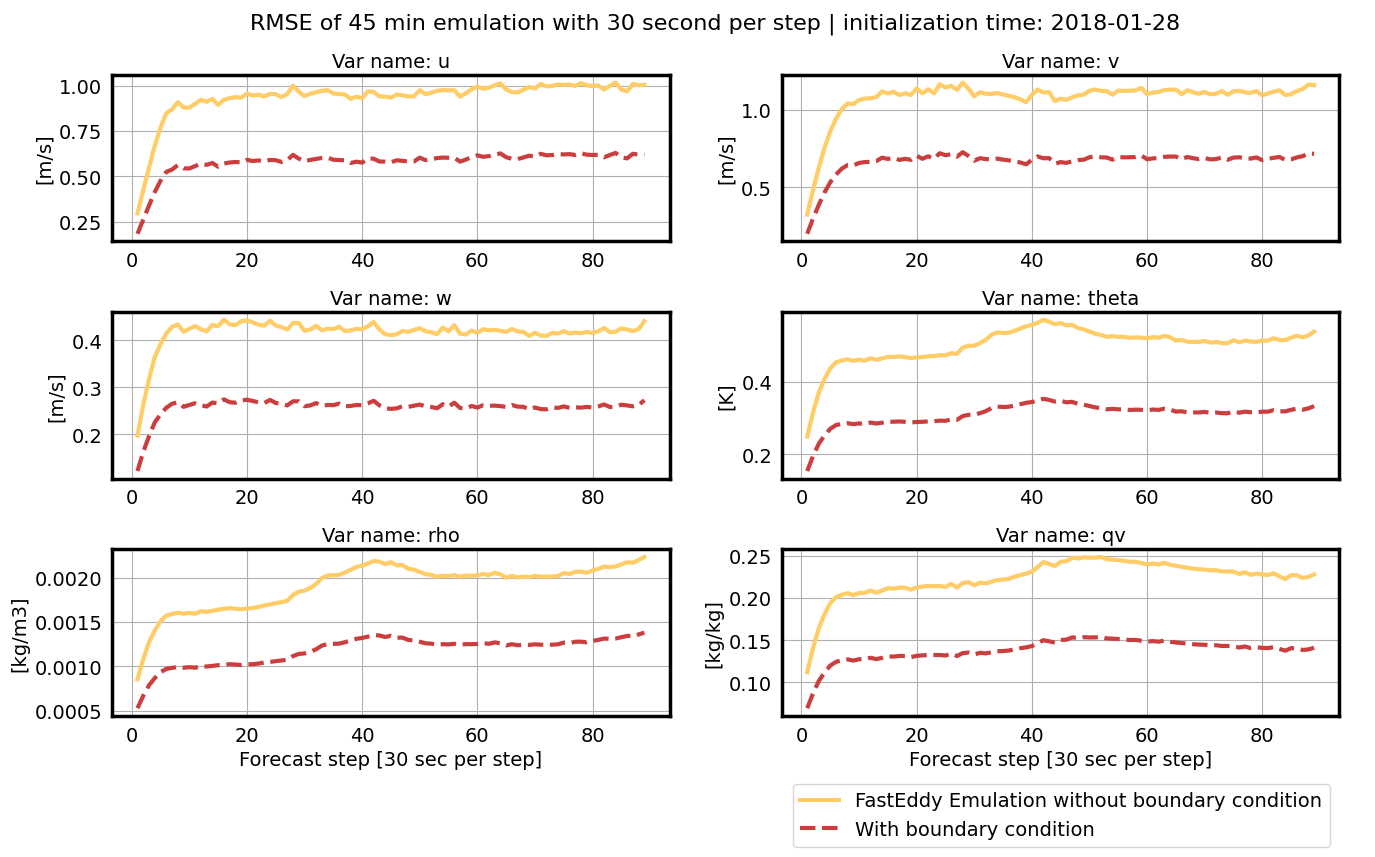

In [72]:
fake_x = np.arange(1, 90)

fig, axs = plt.subplots(3, 2, figsize=(13, 7))
AX = axs.ravel()
plt.tight_layout(w_pad=5, h_pad=3)

for i_var, varname in enumerate(varnames):
    ax = AX[i_var]
    ax = gu.ax_decorate_box(ax)
    ax.tick_params(labelleft=True, labelbottom=True, labelsize=14)
    ax.grid(':')
    ax.plot(fake_x, dict_RMSE[varname], **line_keys['train'])
    ax.plot(fake_x, 0.618*dict_RMSE[varname], **line_keys['valid'])
    
    ax.set_title('Var name: {}'.format(varname), fontsize=14)
    
    if i_var == 4 or i_var == 5:
        ax.set_xlabel('Forecast step [30 sec per step]', fontsize=14)
        plt.legend(loc=0, bbox_to_anchor=(1, -0.35), fontsize=14)


for i in range(3):
    AX[i].set_ylabel('[m/s]', fontsize=14)

AX[3].set_ylabel('[K]', fontsize=14)
AX[4].set_ylabel('[kg/m3]', fontsize=14)
AX[5].set_ylabel('[kg/kg]', fontsize=14)

ax_title1 = fig.add_axes([0.0, 1.025, 1.0, 0.04])

ax_title1.text(
    0.5, 0.5, 
    'RMSE of 45 min emulation with 30 second per step | initialization time: 2018-01-28',
    fontsize=16, va='center', ha='center', transform=ax_title1.transAxes
)

ax_title1.set_axis_off()

## ffmpeg

```bash
ffmpeg -framerate 4 -i anime_surf_%03dk.png -vf "pad=ceil(iw/2)*2:ceil(ih/2)*2" -c:v libx264 -pix_fmt yuv420p output.mp4
```